In [1]:
!python --version

Python 3.10.12


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
%cd /workspace/ViCLIP-OT

/workspace/ViCLIP-OT


## Import libraries

In [4]:
import os
import textwrap
from typing import Literal

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import scienceplots  # noqa: F401
import torch
import torchvision.transforms.v2 as v2
from matplotlib.gridspec import GridSpec
from PIL import Image
from tqdm.autonotebook import tqdm

import viclip_ot.constants as C
import viclip_ot.utils as utils
from viclip_ot.dataset import ImageTextDataset
from viclip_ot.model import ViCLIPOT, ViCLIPOTConfig
from viclip_ot.utils.logger import logger

/tmp/ipykernel_58766/1560164885.py:13: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm
/workspace/ViCLIP-OT/.venv/lib/python3.12/site-packages/timm/models/helpers.py:7: FutureWarning: Importing from timm.models.helpers is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)


## Config

In [5]:
SEED = 42
DATASET_DIR = "./data/UIT-OpenViIC"
TEST_SPLIT_NAME = "test"
MODEL_CONFIG_FILE = "./config/model.vit_base_dinov3_sbert_siglip.yaml"
FROM_CHECKPOINT = "./checkpoints/2026-01-30_01-08-48-ablation_sbert-siglip_loss_lambda_0.1/model_epoch_29_t2i_R__1_0.4151.pth"
DEVICE = "auto"

## Loading model

In [6]:
utils.set_seed(SEED)
device = utils.get_device(DEVICE)
print(f"Using device: {device}")

Using device: cuda


In [7]:
model_config = ViCLIPOTConfig.model_validate(utils.load_yaml_file(MODEL_CONFIG_FILE))
print(f"Model config: {model_config}")
model = ViCLIPOT(config=model_config)
tokenizer = model.text_encoder.tokenizer
model.to(device).eval()
print(f"{model.training}")

Model config: image_config=ViCLIPOTImageConfig(model_name='timm/vit_base_patch16_dinov3.lvd1689m', pretrained=True, pool='avg', proj='linear', proj_bias=False, proj_dropout_rate=0.1) text_config=ViCLIPOTTextConfig(model_name='keepitreal/vietnamese-sbert', pretrained=True, proj='none', proj_bias=False) embed_dim=768 initial_temperature=0.06 logit_bias=-9.0
False


In [8]:
logger.info(f"Loading model from checkpoint: {FROM_CHECKPOINT}")
checkpoint = torch.load(FROM_CHECKPOINT, map_location=device, weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"], strict=True)

2026-02-01 03:09:35.255 | INFO     | __main__:<module>:1 - Loading model from checkpoint: ./checkpoints/2026-01-30_01-08-48-ablation_sbert-siglip_loss_lambda_0.1/model_epoch_29_t2i_R__1_0.4151.pth


<All keys matched successfully>

## Loading test data

In [9]:
eval_transforms = v2.Compose(
    [
        v2.Resize(size=256, interpolation=v2.InterpolationMode.BICUBIC),
        v2.CenterCrop(size=224),
        v2.ToTensor(),
        v2.Normalize(
            mean=C.IMAGENET_DEFAULT_MEAN,
            std=C.IMAGENET_DEFAULT_STD,
        ),
    ]
)


def model_fmt() -> Literal["gemma", "e5", "qwen3", "bge", "sbert"]:
    model_name = model_config.text_config.model_name
    if "gemma" in model_name.lower():  # google/embeddinggemma-300m
        return "gemma"
    elif "e5" in model_name.lower():  # intfloat/multilingual-e5-large
        return "e5"
    elif "qwen" in model_name.lower():  # Qwen/Qwen3-Embedding-0.6B
        return "qwen3"
    elif "bge" in model_name.lower():  # BAAI/bge-m3
        return "bge"
    elif "sbert" in model_name.lower():  # keepitreal/vietnamese-sbert
        return "sbert"
    else:
        raise ValueError(f"Unsupported model name for determining model format: {model_name}")


logger.info(f"Determined model format: {model_fmt()}")

test_dataset = ImageTextDataset(
    root_dir=DATASET_DIR,
    metadata_json_file=f"{TEST_SPLIT_NAME}.json",
    image_transforms=eval_transforms,
    model_fmt=model_fmt(),
)

/workspace/ViCLIP-OT/.venv/lib/python3.12/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
2026-02-01 03:09:36.588 | INFO     | __main__:<module>:30 - Determined model format: sbert
2026-02-01 03:09:36.589 | INFO     | viclip_ot.dataset:__init__:77 - Loading image text data from: ./data/UIT-OpenViIC/test.json
2026-02-01 03:09:36.623 | INFO     | viclip_ot.dataset:__init__:81 - Found 2001 images and 10001 annotations.


## Image retrieval from text query

### Embedding images

In [10]:
all_image_features = []
all_sample_indices = []
batch_size = 32
with torch.no_grad():
    progress_bar = tqdm(range(0, len(test_dataset), batch_size), "Embedding images")
    for start_idx in progress_bar:
        end_idx = min(len(test_dataset), start_idx + batch_size)

        images = []
        for j in range(start_idx, end_idx):
            sample = test_dataset[j]
            images.append(sample[0])
            all_sample_indices.append(sample[3])

        images = torch.stack(images).to(device)

        image_features = model.encode_image(images, normalize=True)

        all_image_features.append(image_features.cpu())

    all_image_features = torch.cat(all_image_features, dim=0)

print(f"{all_image_features.shape = }")

Embedding images:   0%|          | 0/63 [00:00<?, ?it/s]

2026-02-01 03:10:11.352 | WARNING  | viclip_ot.dataset:__getitem__:141 - Corrupt image at ./data/UIT-OpenViIC/./images/00000005095.jpg, skipping. Error: image file is truncated (76 bytes not processed)
2026-02-01 03:10:17.899 | WARNING  | viclip_ot.dataset:__getitem__:141 - Corrupt image at ./data/UIT-OpenViIC/./images/00000001010.jpg, skipping. Error: image file is truncated (155 bytes not processed)
2026-02-01 03:10:18.250 | WARNING  | viclip_ot.dataset:__getitem__:141 - Corrupt image at ./data/UIT-OpenViIC/./images/00000000768.jpg, skipping. Error: image file is truncated (18 bytes not processed)


all_image_features.shape = torch.Size([2001, 768])


### Embedding text queries

In [11]:
text_queries = [
    "Phở",
    "Áo dài",
    "Cô gái mặc áo dài màu đỏ",
    # "Phố cổ vào ban đêm",
    "Phố cổ với nhiều lồng đèn",
    "Thuyền trên sông lúc hoàng hôn",
    # "Trẻ em chơi đùa trên bãi biển",
]
translated_queries = [
    "Pho",
    "Ao dai",
    "A girl in a red Ao dai",
    # "Old Quarter at night",
    "Old town with many lanterns",
    "Boat on the river at sunset",
    # "Children playing on the beach",
]

In [12]:
all_text_features = []
batch_size = 32
with torch.no_grad():
    progress_bar = tqdm(range(0, len(text_queries), batch_size), "Embedding text")
    for start_idx in progress_bar:
        end_idx = min(len(text_queries), start_idx + batch_size)
        text_inputs = tokenizer(
            [query.lower() for query in text_queries[start_idx:end_idx]],
            padding=True,
            truncation=True,
            max_length=2048,
            return_tensors="pt",
        ).to(device)

        text_features = model.encode_text(text_inputs, normalize=True)

        all_text_features.append(text_features.cpu())

    all_text_features = torch.cat(all_text_features, dim=0)

print(f"{all_text_features.shape = }")

Embedding text:   0%|          | 0/1 [00:00<?, ?it/s]

all_text_features.shape = torch.Size([5, 768])


In [13]:
logits_t2i = all_text_features @ all_image_features.t()
print(f"{logits_t2i.shape = }")

logits_t2i.shape = torch.Size([5, 2001])


### Visualizing image retrieval results

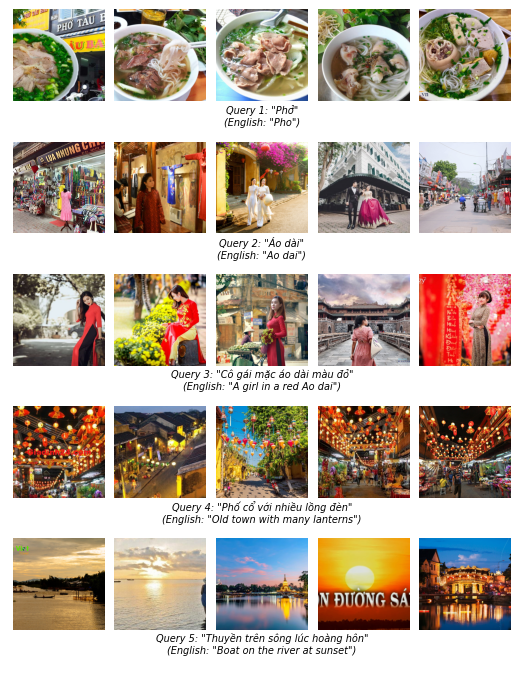

In [14]:
np.random.seed(SEED)
num_queries = len(text_queries)
top_k = 5

# Figure dimensions for elsarticle preprint (text width ~6.5 inches)
fig_width = 6.5  # inches, suitable for single-column preprint
img_aspect_ratio = 1.0  # width/height ratio for displayed images (square)
img_width = fig_width / top_k  # width per image
img_height = img_width / img_aspect_ratio  # height per image
query_text_space = 0.4  # space for query text below images
row_height = img_height + query_text_space
fig_height = row_height * num_queries

# Create figure with GridSpec for better control
fig = plt.figure(figsize=(fig_width, fig_height))
gs = GridSpec(
    num_queries * 2,
    top_k,  # 2 rows per query: one for images, one for text
    figure=fig,
    height_ratios=[img_height, query_text_space] * num_queries,
    hspace=0.1,
    wspace=0.05,
)

for row, query_idx in enumerate(range(len(all_text_features))):
    similarities = logits_t2i[query_idx]
    query_text = text_queries[query_idx]

    # Get top-k indices sorted by decreasing similarity
    top_k_indices = torch.argsort(similarities, descending=True)[:top_k]
    top_k_scores = similarities[top_k_indices]

    # Display top-k retrieved images with consistent dimensions
    for col, (img_idx, score) in enumerate(zip(top_k_indices, top_k_scores, strict=True)):
        img_idx = img_idx.item()

        # Get the image from dataset using unique_image_ids mapping
        image_path = test_dataset.samples[all_sample_indices[img_idx]][1]  # pyright: ignore
        image = mpimg.imread(image_path)

        # Create axes for image
        ax = fig.add_subplot(gs[row * 2, col])

        # Center crop image to square for consistent display
        h, w = image.shape[:2]
        min_dim = min(h, w)
        start_h = (h - min_dim) // 2
        start_w = (w - min_dim) // 2
        cropped_image = image[start_h : start_h + min_dim, start_w : start_w + min_dim]

        ax.imshow(cropped_image)
        ax.axis("off")
        # ax.set_title(f"Sim: {score.item():.3f}", fontsize=7, pad=2)

    # Create a spanning axes for query text below the images
    ax_text = fig.add_subplot(gs[row * 2 + 1, :])
    ax_text.axis("off")

    # Display query text centered below the images
    # y=1.0 places text at top of text area (close to images above)
    wrapped_text = textwrap.fill(query_text, width=60)
    translated_text = translated_queries[query_idx]
    ax_text.text(
        0.5,
        1.1,
        f'Query {row + 1}: "{wrapped_text}"\n(English: "{translated_text}")',
        ha="center",
        va="top",
        fontsize=7,
        style="italic",
        transform=ax_text.transAxes,
    )

plt.savefig("t2i_retrieval_examples.pdf", bbox_inches="tight", dpi=300)
plt.show()

## Image retrieval from image query

In [15]:
# image from test set
image_query_files = [
    # "00000000763.jpg",  # query 1
    # "00000000728.jpg",  # query 2
    # "00000010187.jpg",  # query 3
    # "00000010186.jpg",  # query 4
    # "00000010160.jpg",  # query 5
    # "00000010136.jpg",  # query 6
    # "00000009976.jpg",  # query 7
    # "00000009935.jpg",  # query 8
    "00000009913.jpg",  # query 9
    # "00000009812.jpg",  # query 10
    # "00000009680.jpg",  # query 11
    "00000009621.jpg",  # query 12
    # "00000009616.jpg",  # query 13
    # "00000009349.jpg",  # query 14
    # "00000009336.jpg",  # query 15
    # "00000009318.jpg",  # query 16
    "00000009177.jpg",  # query 17
    "00000008793.jpg",  # query 18
    "00000008790.jpg",  # query 19
]

image_query_file_paths = [os.path.join(DATASET_DIR, "images", f) for f in image_query_files]
all_image_query_features = []
batch_size = 32
with torch.no_grad():
    progress_bar = tqdm(range(0, len(image_query_file_paths), batch_size), "Embedding image query")
    for start_idx in progress_bar:
        end_idx = min(len(image_query_file_paths), start_idx + batch_size)

        images = []
        for j in range(start_idx, end_idx):
            image_path = image_query_file_paths[j]
            try:
                image = Image.open(image_path)
                # handle palette images with transparency
                if image.mode == "P" and "transparency" in image.info:
                    image = image.convert("RGBA")

                image = image.convert("RGB")

            except (OSError, SyntaxError) as e:
                raise RuntimeError(f"Error opening image file {image_path}: {e}")

            image = eval_transforms(image)
            images.append(image)

        image_inputs = torch.stack(images).to(device)
        image_features = model.encode_image(image_inputs, normalize=True)

        all_image_query_features.append(image_features.cpu())
    all_image_query_features = torch.cat(all_image_query_features, dim=0)

print(f"{all_image_query_features.shape = }")

Embedding image query:   0%|          | 0/1 [00:00<?, ?it/s]

all_image_query_features.shape = torch.Size([5, 768])


In [16]:
logits_i2i = all_image_query_features @ all_image_features.t()
print(f"{logits_i2i.shape = }")

logits_i2i.shape = torch.Size([5, 2001])


### Visualizing image retrieval results

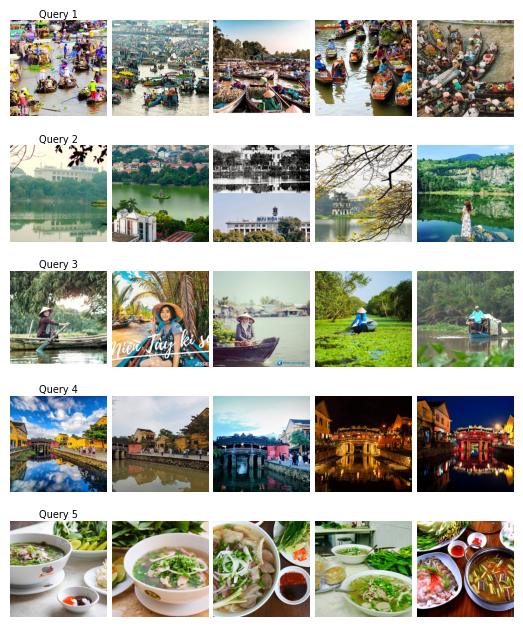

In [17]:
# Visualize image-to-image retrieval
num_image_queries = len(image_query_files)
top_k_i2i = 4  # number of retrieved images (excluding query)
total_cols = top_k_i2i + 1  # query image + top-k retrieved

# Figure dimensions for elsarticle preprint
fig_width_i2i = 6.5
img_aspect_ratio_i2i = 1.0
img_width_i2i = fig_width_i2i / total_cols
img_height_i2i = img_width_i2i / img_aspect_ratio_i2i
row_spacing = 0.25  # space between rows
fig_height_i2i = (img_height_i2i + row_spacing) * num_image_queries

fig_i2i = plt.figure(figsize=(fig_width_i2i, fig_height_i2i))
gs_i2i = GridSpec(
    num_image_queries,
    total_cols,
    figure=fig_i2i,
    hspace=0.3,
    wspace=0.05,
)

for row, query_idx in enumerate(range(num_image_queries)):
    similarities = logits_i2i[query_idx]

    # Get top-k indices sorted by decreasing similarity (exclude self if in dataset)
    top_k_indices = torch.argsort(similarities, descending=True)[: top_k_i2i + 1]
    top_k_scores = similarities[top_k_indices]

    # Display query image in first column
    query_image_path = image_query_file_paths[query_idx]
    query_image = mpimg.imread(query_image_path)

    ax_query = fig_i2i.add_subplot(gs_i2i[row, 0])

    # Center crop query image to square
    h, w = query_image.shape[:2]
    min_dim = min(h, w)
    start_h = (h - min_dim) // 2
    start_w = (w - min_dim) // 2
    cropped_query = query_image[start_h : start_h + min_dim, start_w : start_w + min_dim]

    ax_query.imshow(cropped_query)
    ax_query.axis("off")
    ax_query.set_title(f"Query {row + 1}", fontsize=7, pad=2)
    # Add border to distinguish query image
    for spine in ax_query.spines.values():
        spine.set_visible(True)
        spine.set_color("blue")
        spine.set_linewidth(2)

    # Display top-k retrieved images
    col_offset = 1
    results_shown = 0
    for img_idx, score in zip(top_k_indices, top_k_scores, strict=True):
        if results_shown >= top_k_i2i:
            break
        img_idx = img_idx.item()

        # Get the image from dataset
        image_path = test_dataset.samples[all_sample_indices[img_idx]][1]  # pyright: ignore

        # Skip if same as query image
        if os.path.basename(image_path) == image_query_files[query_idx]:
            continue

        image = mpimg.imread(image_path)

        ax = fig_i2i.add_subplot(gs_i2i[row, col_offset + results_shown])

        # Center crop image to square
        h, w = image.shape[:2]
        min_dim = min(h, w)
        start_h = (h - min_dim) // 2
        start_w = (w - min_dim) // 2
        cropped_image = image[start_h : start_h + min_dim, start_w : start_w + min_dim]

        ax.imshow(cropped_image)
        ax.axis("off")
        # ax.set_title(f"Rank {results_shown + 1}\nSim: {score.item():.3f}", fontsize=7, pad=2)

        results_shown += 1

plt.savefig("i2i_retrieval_examples.pdf", bbox_inches="tight", dpi=300)
plt.show()